In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection  import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error,confusion_matrix, precision_score, recall_score, auc,roc_curve
from sklearn import ensemble, linear_model, neighbors, svm, tree, neural_network
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn import svm,model_selection, tree, linear_model, neighbors, naive_bayes, ensemble, discriminant_analysis, gaussian_process

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import LabelEncoder

In [39]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
!pip install imbalanced-learn xgboost scikit-learn


In [41]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [42]:
data = pd.read_csv('/content/drive/MyDrive/AI Dataset/Lung Cancer prediction.csv')

In [43]:
data.head(10)

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO
5,F,75,1,2,1,1,2,2,2,2,1,2,2,1,1,YES
6,M,52,2,1,1,1,1,2,1,2,2,2,2,1,2,YES
7,F,51,2,2,2,2,1,2,2,1,1,1,2,2,1,YES
8,F,68,2,1,2,1,1,2,1,1,1,1,1,1,1,NO
9,M,53,2,2,2,2,2,1,2,1,2,1,1,2,2,YES


In [44]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 309 non-null    object
 1   AGE                    309 non-null    int64 
 2   SMOKING                309 non-null    int64 
 3   YELLOW_FINGERS         309 non-null    int64 
 4   ANXIETY                309 non-null    int64 
 5   PEER_PRESSURE          309 non-null    int64 
 6   CHRONIC DISEASE        309 non-null    int64 
 7   FATIGUE                309 non-null    int64 
 8   ALLERGY                309 non-null    int64 
 9   WHEEZING               309 non-null    int64 
 10  ALCOHOL CONSUMING      309 non-null    int64 
 11  COUGHING               309 non-null    int64 
 12  SHORTNESS OF BREATH    309 non-null    int64 
 13  SWALLOWING DIFFICULTY  309 non-null    int64 
 14  CHEST PAIN             309 non-null    int64 
 15  LUNG_CANCER            

In [45]:
data.describe()


,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
count,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,62.673139,1.563107,1.569579,1.498382,1.501618,1.504854,1.673139,1.556634,1.556634,1.556634,1.579288,1.640777,1.469256,1.556634
std,8.210301,0.496806,0.495938,0.500808,0.500808,0.500787,0.469827,0.497588,0.497588,0.497588,0.494474,0.480551,0.499863,0.497588
min,21.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,57.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,62.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000
75%,69.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,87.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


In [46]:
data.isnull().sum()

,0
GENDER,0
AGE,0
SMOKING,0
YELLOW_FINGERS,0
ANXIETY,0
PEER_PRESSURE,0
CHRONIC DISEASE,0
FATIGUE,0
ALLERGY,0
WHEEZING,0


<Axes: >

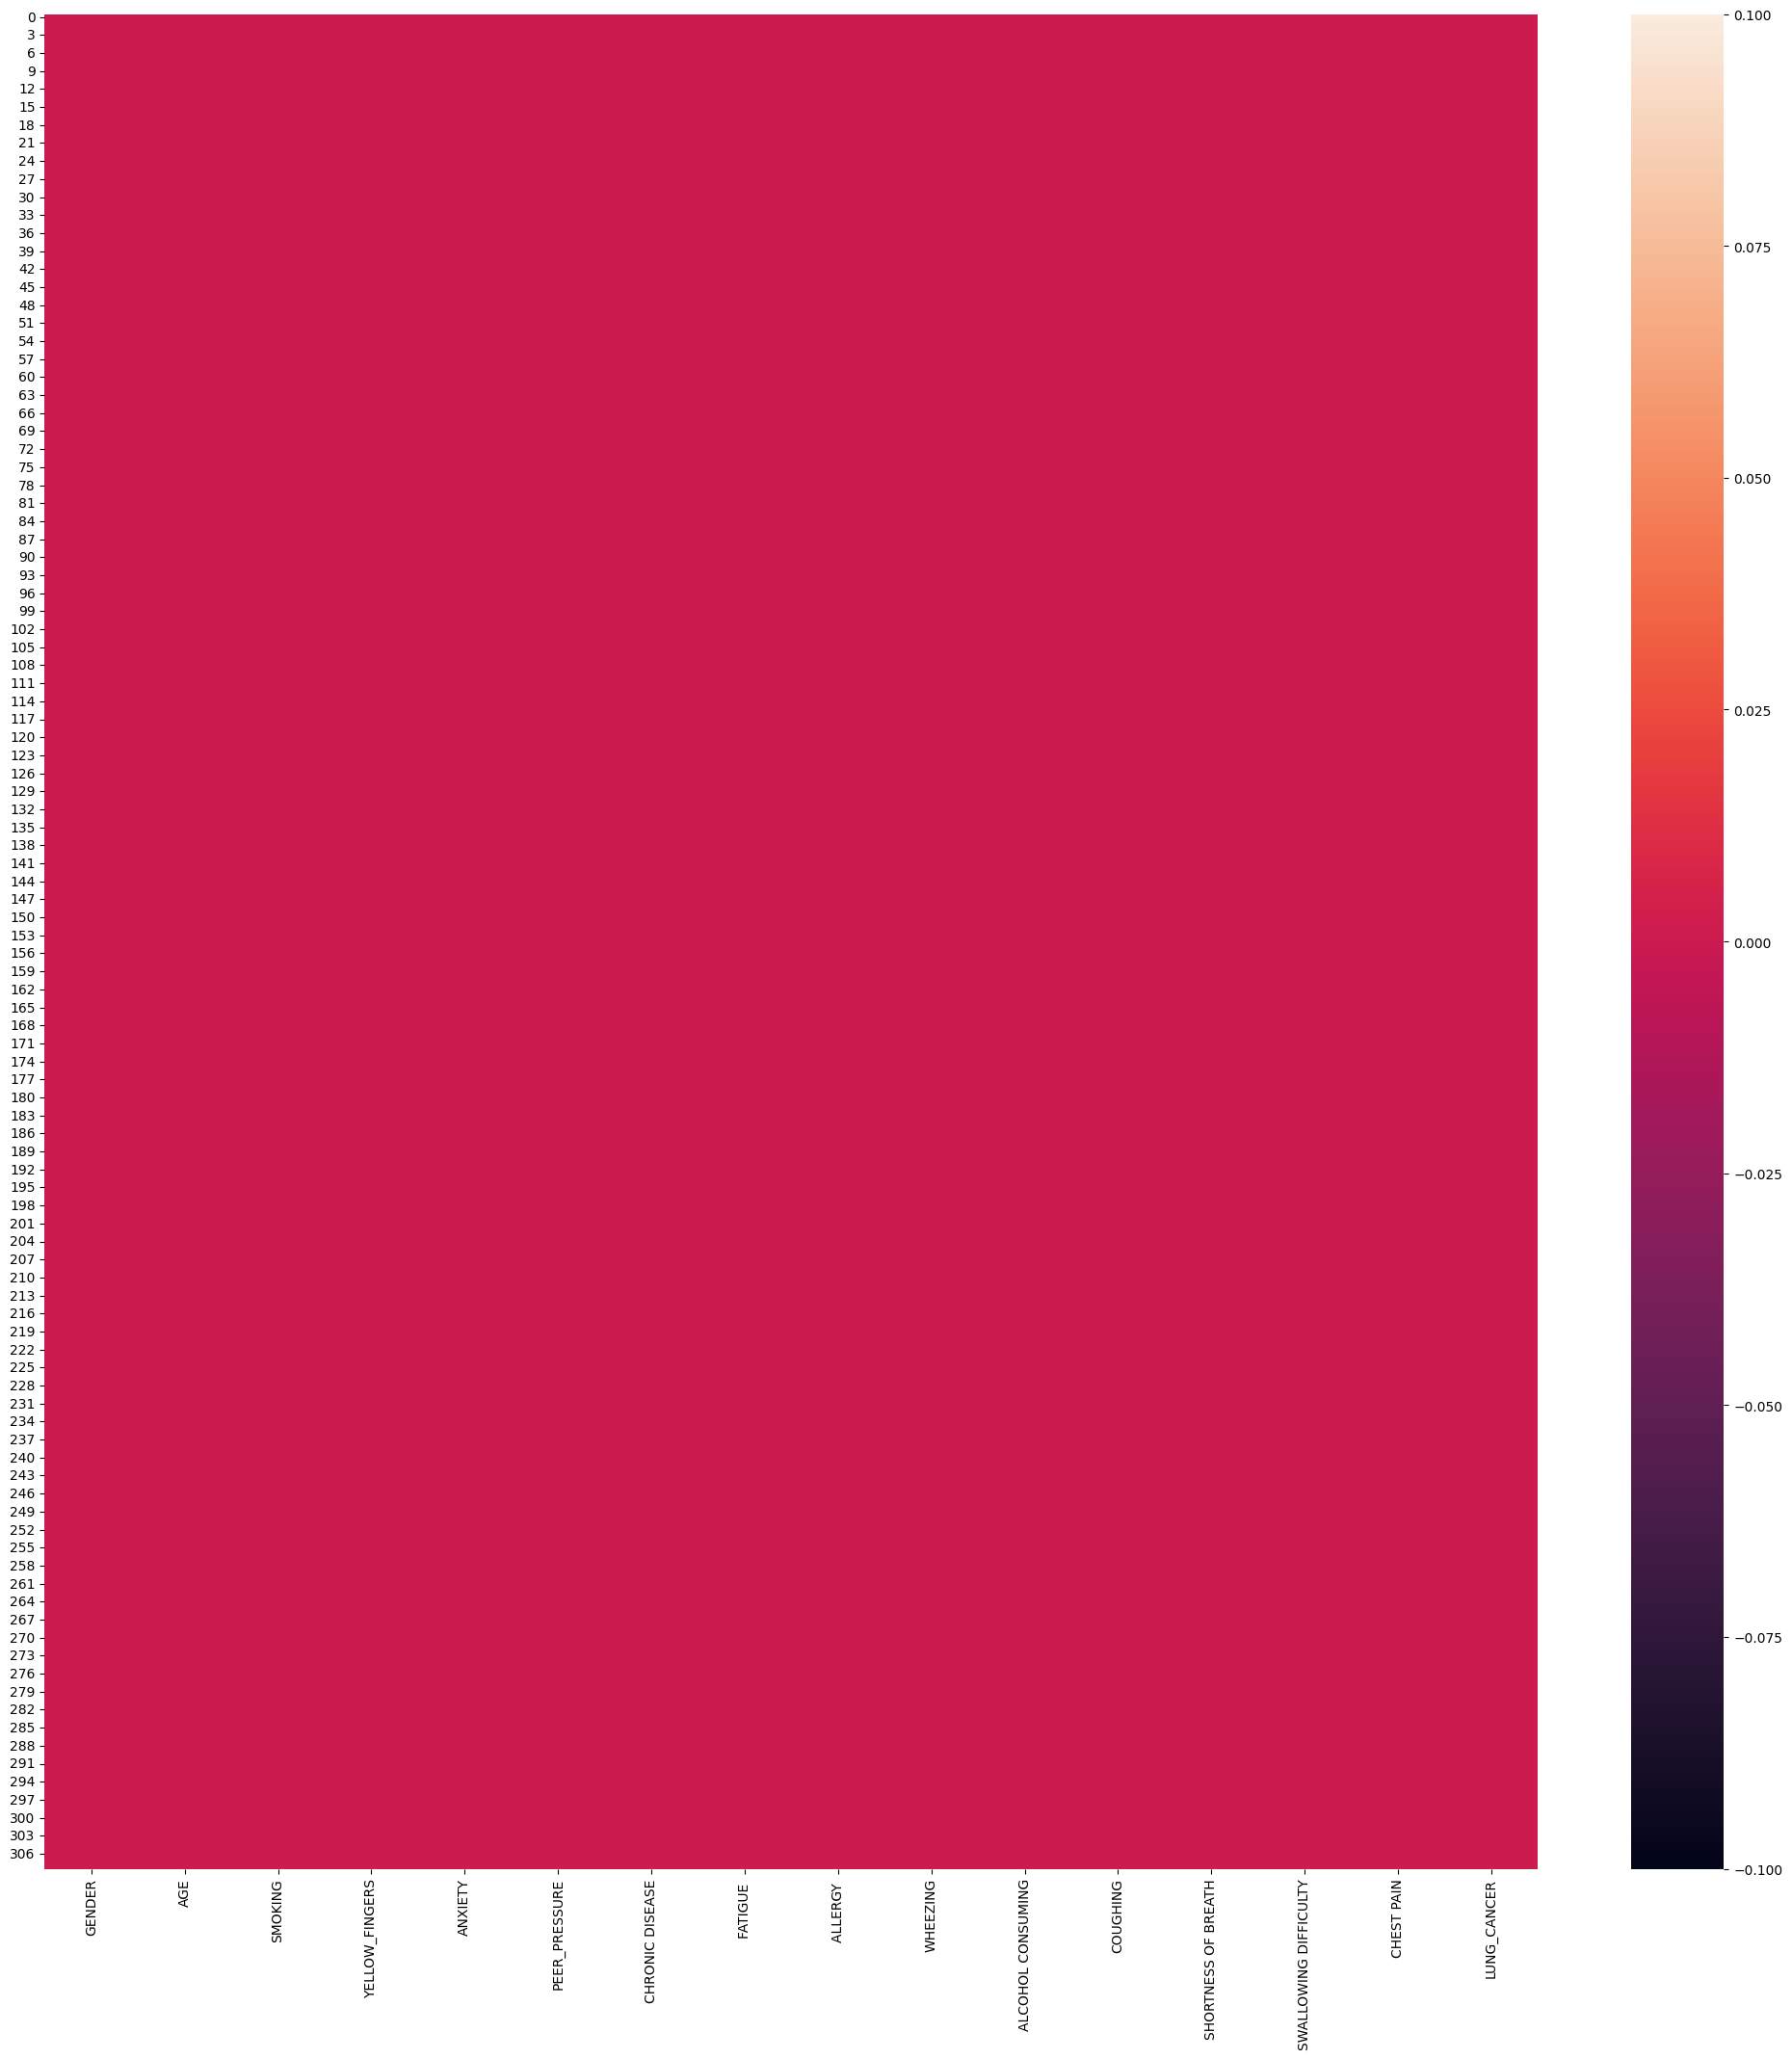

In [47]:
plt.figure(figsize=(25,25))
sns.heatmap(data.isnull())

In [48]:
data.shape[0]

309

In [49]:
null_var = data.isnull().sum()/data.shape[0] *100
null_var

,0
GENDER,0.0
AGE,0.0
SMOKING,0.0
YELLOW_FINGERS,0.0
ANXIETY,0.0
PEER_PRESSURE,0.0
CHRONIC DISEASE,0.0
FATIGUE,0.0
ALLERGY,0.0
WHEEZING,0.0


In [50]:
drop_columns  = null_var[null_var >17].keys()
drop_columns

Index([], dtype='object')

In [51]:
data2_drop_clm=data.drop(columns=drop_columns)

In [52]:
data2_drop_clm.shape

(309, 16)

In [53]:
numerical_columns = data2_drop_clm.select_dtypes(include=['int64', 'float64']).columns
data2_drop_clm[numerical_columns] = data2_drop_clm[numerical_columns].fillna(data2_drop_clm[numerical_columns].mean())

object_columns = data2_drop_clm.select_dtypes(include=['object']).columns
for col in object_columns:
    mode_value = data2_drop_clm[col].mode()[0]
    data2_drop_clm[col] = data2_drop_clm[col].fillna(mode_value)

In [54]:
data2_drop_clm.shape

(309, 16)

<Axes: >

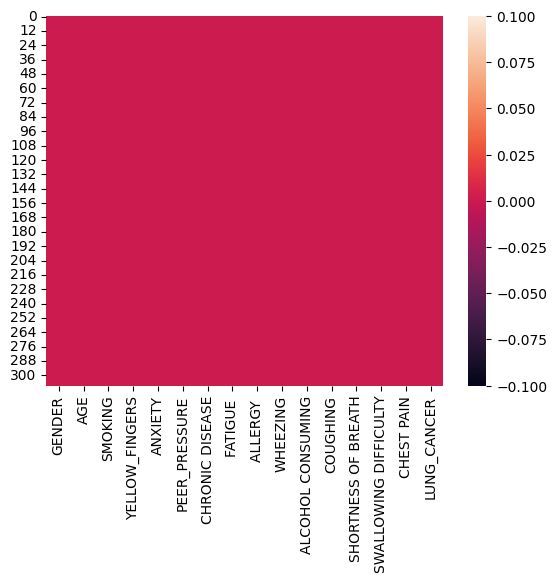

In [55]:
sns.heatmap(data2_drop_clm.isnull())

Data Preprocessing

In [56]:


# Convert categorical variables
data['GENDER'] = data['GENDER'].map({'M':1, 'F':0})
data['LUNG_CANCER'] = data['LUNG_CANCER'].map({'YES':1, 'NO':0})

# Split data
X = data.drop('LUNG_CANCER', axis=1)
y = data['LUNG_CANCER']


In [57]:
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN

balancers = {
    'SMOTE': SMOTE(random_state=42),
    'ADASYN': ADASYN(random_state=42),
    'ROS': RandomOverSampler(random_state=42),
    'RUS': RandomUnderSampler(random_state=42),
    'SMOTEENN': SMOTEENN(random_state=42)
}

# Example usage for SMOTE
X_bal, y_bal = SMOTE().fit_resample(X, y)


In [58]:
X = data.drop('LUNG_CANCER', axis=1)
y = data['LUNG_CANCER']


In [59]:
print(data['LUNG_CANCER'].value_counts())


LUNG_CANCER
1    270
0     39
Name: count, dtype: int64


In [60]:
import pandas as pd

class_distribution = {'YES': 270, 'NO': 39}

# Convert to DataFrame
df_class_distribution = pd.DataFrame(list(class_distribution.items()), columns=['LUNG_CANCER', 'Count'])

# Calculate the proportion
df_class_distribution['Proportion'] = df_class_distribution['Count'] / df_class_distribution['Count'].sum()

print(df_class_distribution)


  LUNG_CANCER  Count  Proportion
0         YES    270    0.873786
1          NO     39    0.126214


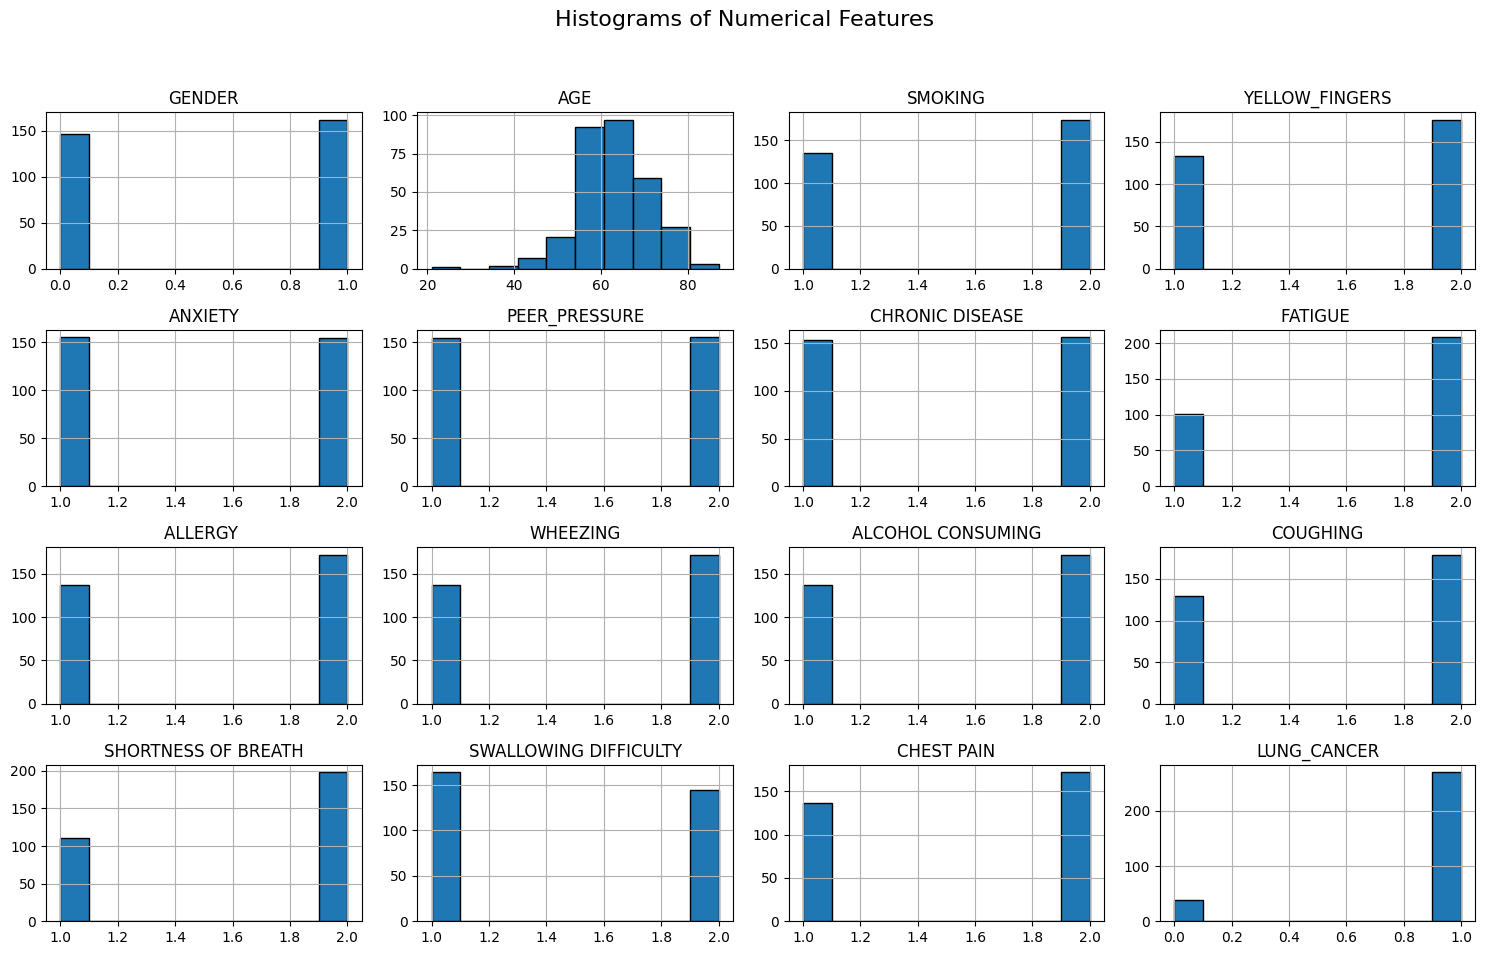

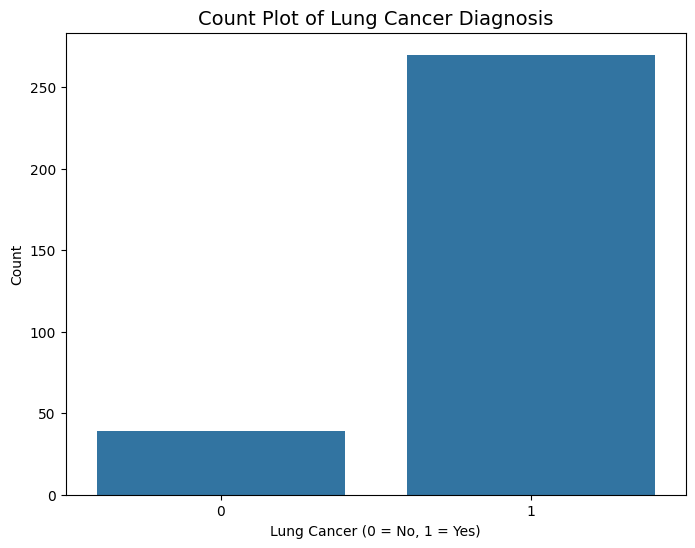

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'data' is your DataFrame containing the lung cancer data

# 1. Plot histograms for numerical features
numerical_features = data.select_dtypes(include=['int64', 'float64']).columns
data[numerical_features].hist(figsize=(15, 10), bins=10, edgecolor='black')
plt.suptitle('Histograms of Numerical Features', fontsize=16) # Added overall title
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

# 2. Plot count plot for the categorical feature 'LUNG_CANCER'
plt.figure(figsize=(8, 6))
sns.countplot(x='LUNG_CANCER', data=data)
plt.title('Count Plot of Lung Cancer Diagnosis', fontsize=14)
plt.xlabel('Lung Cancer (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

# 3. Plot count plots for other categorical features (if any)
categorical_features = data.select_dtypes(include=['object']).columns
for feature in categorical_features:
    if feature != 'LUNG_CANCER':  # Already plotted above
        plt.figure(figsize=(8, 6))
        sns.countplot(x=feature, data=data)
        plt.title(f'Count Plot of {feature}', fontsize=14)
        plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels if needed
        plt.ylabel('Count')
        plt.show()

In [62]:
data.isnull().sum()

,0
GENDER,0
AGE,0
SMOKING,0
YELLOW_FINGERS,0
ANXIETY,0
PEER_PRESSURE,0
CHRONIC DISEASE,0
FATIGUE,0
ALLERGY,0
WHEEZING,0


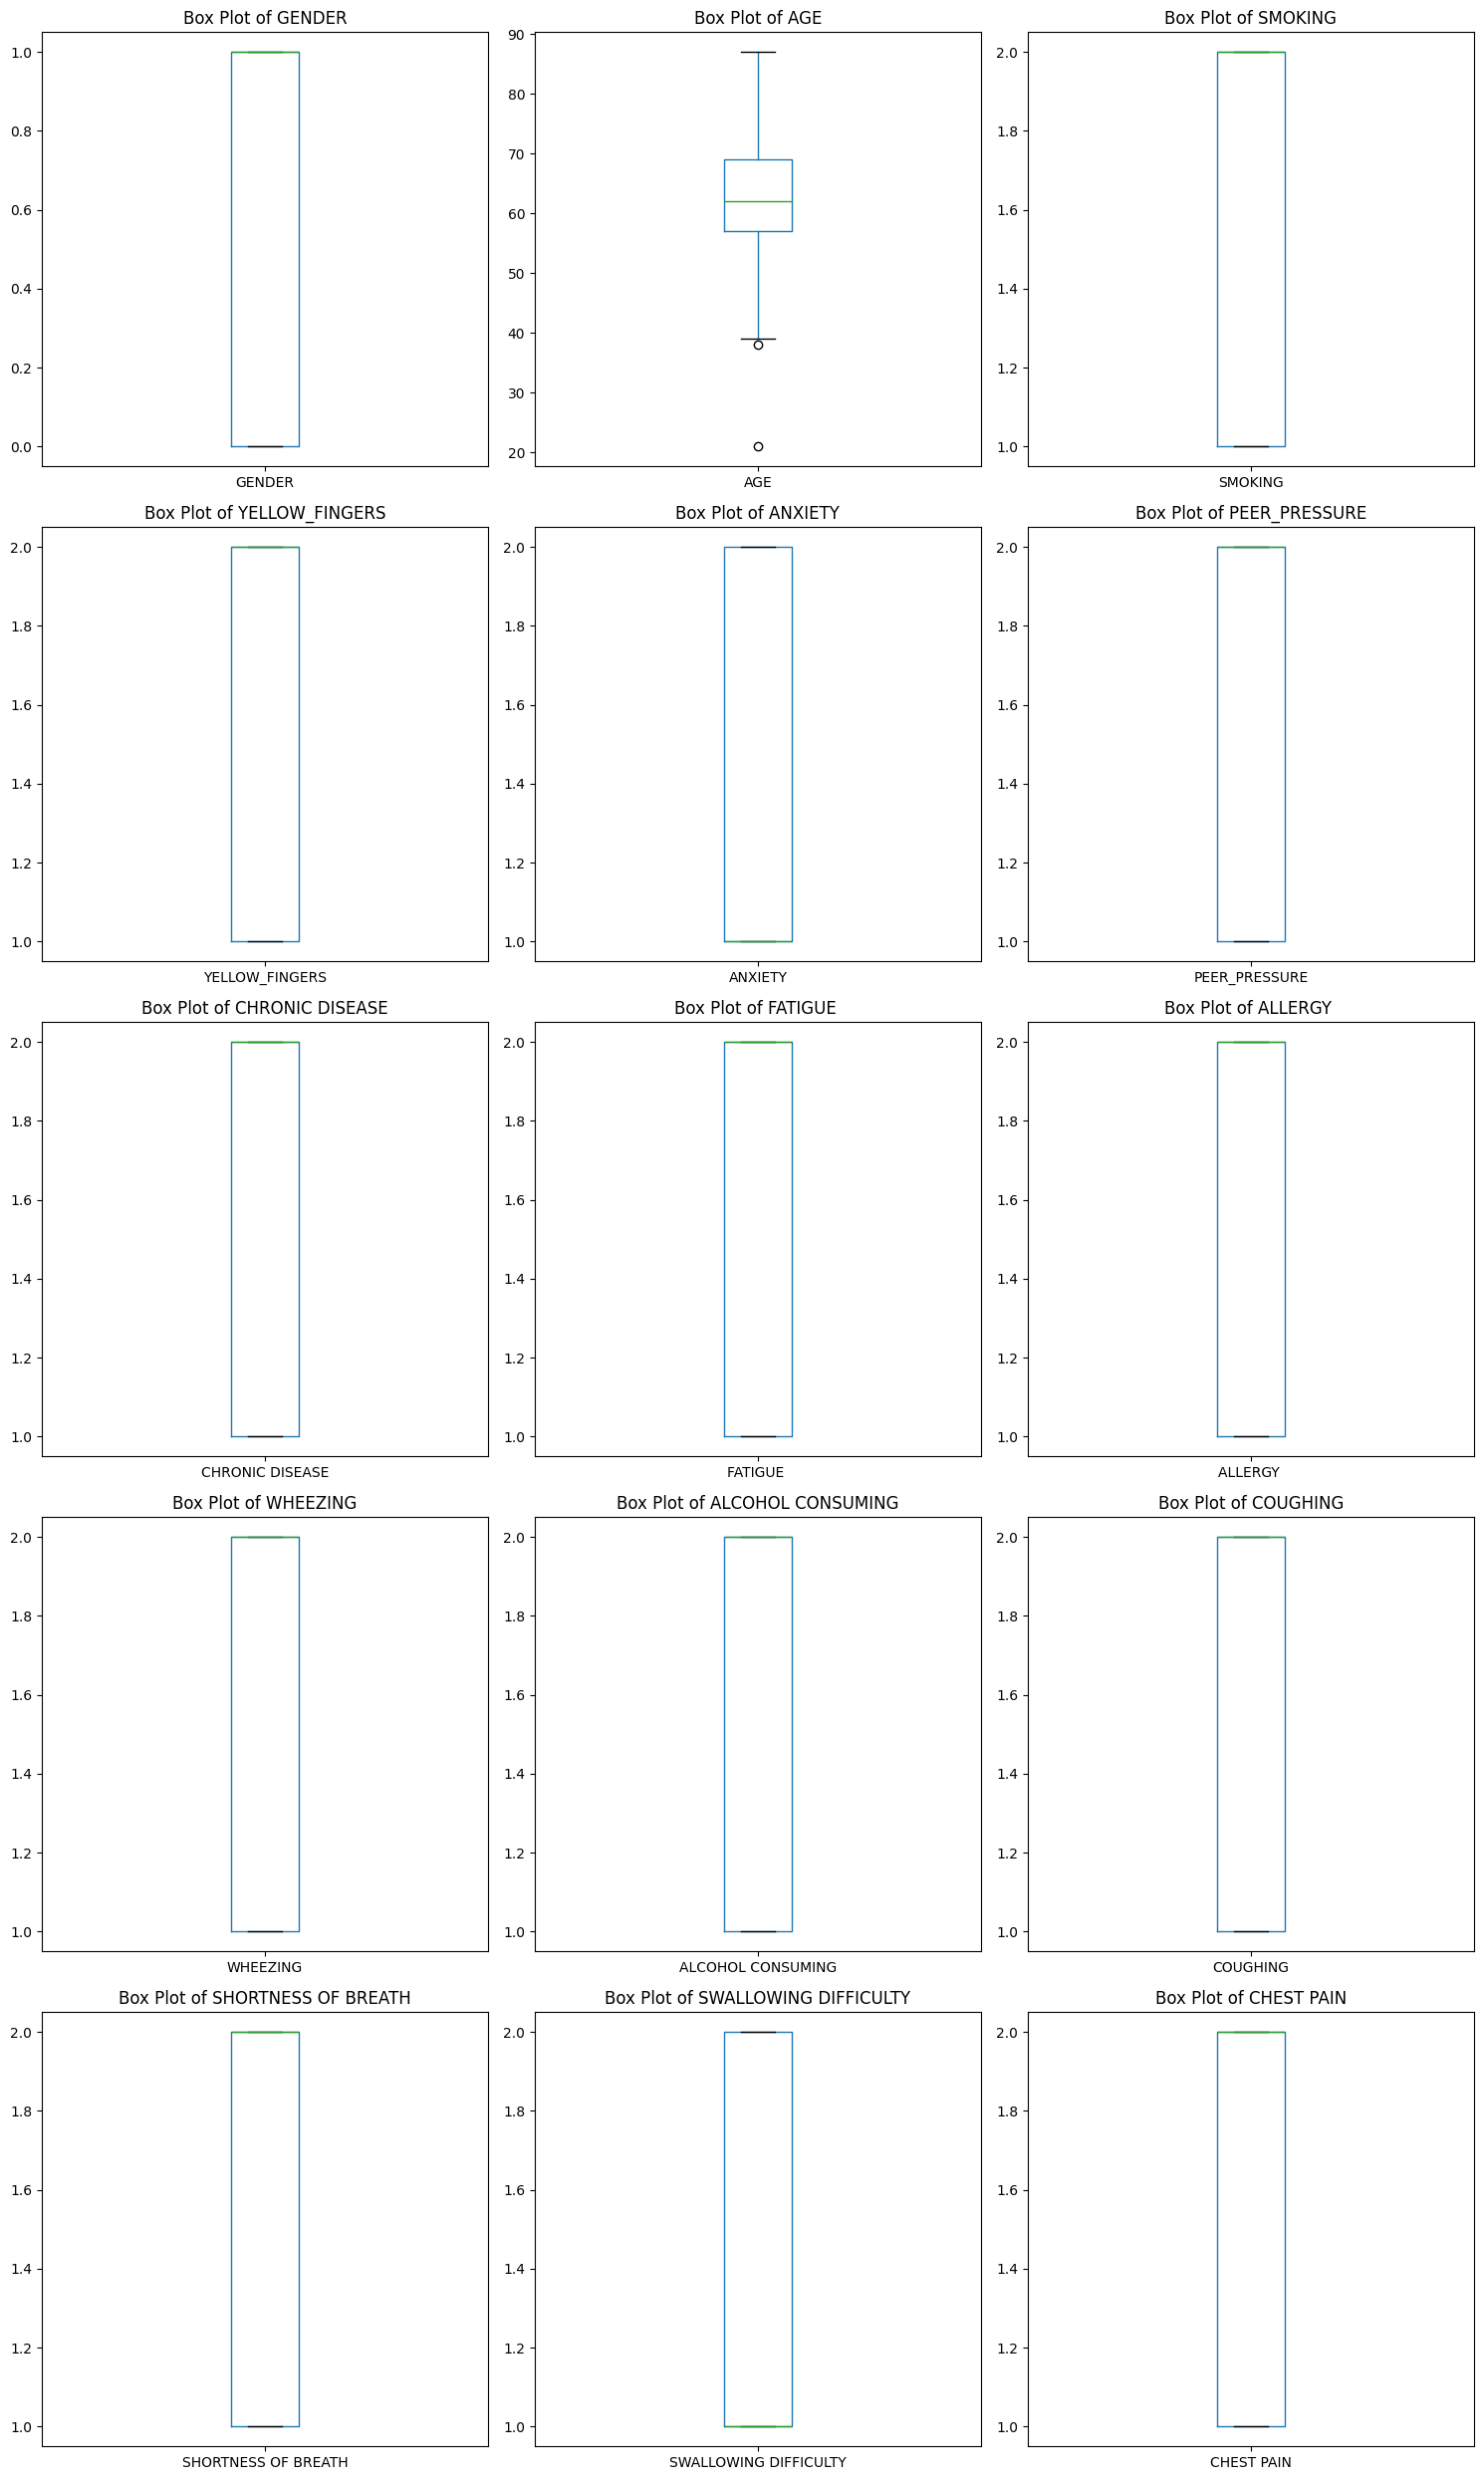

In [63]:
import matplotlib.pyplot as plt
import math

# Get numerical features
# Use 'data' instead of 'df'
numerical_features = data.drop('LUNG_CANCER', axis=1).select_dtypes(include=['int64', 'float64']).columns

# Calculate number of rows and columns for subplots
num_features = len(numerical_features)
num_cols = 3  # Number of columns in the subplot grid
num_rows = math.ceil(num_features / num_cols)  # Calculate rows needed

# Create figure and subplots
plt.figure(figsize=(15, 5 * num_rows))  # Adjust figure height based on rows
for i, feature in enumerate(numerical_features):
    plt.subplot(num_rows, num_cols, i + 1)  # i + 1 for correct subplot indexing
    # Use 'data' instead of 'df'
    data.boxplot(column=[feature])
    plt.title(f'Box Plot of {feature}')
    plt.grid(False)

plt.tight_layout()
plt.show()

Feature Selection

In [64]:
from sklearn.feature_selection import (SelectKBest, chi2, mutual_info_classif,
                                       RFE, SelectFromModel)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LassoCV

def feature_selection(X, y):
    # Univariate Selection
    selector_kbest = SelectKBest(chi2, k=8).fit(X, y)

    # Recursive Elimination
    selector_rfe = RFE(RandomForestClassifier(), n_features_to_select=8).fit(X, y)

    # Tree-based Importance
    forest = RandomForestClassifier().fit(X, y)
    feat_imp = forest.feature_importances_

    # L1 Regularization
    lasso = SelectFromModel(LassoCV()).fit(X, y)

    # Mutual Information
    selector_mi = SelectKBest(mutual_info_classif, k=8).fit(X, y)

    return {
        'KBest': X.columns[selector_kbest.get_support()],
        'RFE': X.columns[selector_rfe.get_support()],
        'Lasso': X.columns[lasso.get_support()],
        'MutualInfo': X.columns[selector_mi.get_support()]
    }


Model Training

In [65]:
# Encode categorical variables
le_gender = LabelEncoder()
le_cancer = LabelEncoder()
data['GENDER'] = le_gender.fit_transform(data['GENDER'])
data['LUNG_CANCER'] = le_cancer.fit_transform(data['LUNG_CANCER'])

In [66]:
# Split features and target
X = data.drop('LUNG_CANCER', axis=1)
y = data['LUNG_CANCER']


In [67]:
# Apply SMOTE to balance classes
smote = SMOTE(random_state=42)
X_bal, y_bal = smote.fit_resample(X, y)


In [68]:
# Feature selection (example: RFE with RandomForest)
selector = RFE(RandomForestClassifier(n_estimators=100, random_state=42), n_features_to_select=8)
selector.fit(X_bal, y_bal)
selected_features = X.columns[selector.support_]
X_selected = X_bal[selected_features]


In [71]:
# Define models
from xgboost import XGBClassifier # Import XGBClassifier from xgboost
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

In [72]:
# Evaluation function
def evaluate_models(X, y):
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    results = {}
    for name, model in models.items():
        scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
        results[name] = {
            'Mean AUC': scores.mean(),
            'Std Dev': scores.std()
        }
    return pd.DataFrame(results).T


In [76]:
# Evaluation function
from sklearn.model_selection import StratifiedKFold # Import StratifiedKFold
def evaluate_models(X, y):
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    results = {}
    for name, model in models.items():
        scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
        results[name] = {
            'Mean AUC': scores.mean(),
            'Std Dev': scores.std()
        }
    return pd.DataFrame(results).T

In [77]:
# Evaluate
results = evaluate_models(X_selected, y_bal)
print(results)


                     Mean AUC   Std Dev
Random Forest        0.983196  0.018009
XGBoost              0.966735  0.028845
SVM                  0.723800  0.045774
Logistic Regression  0.977298  0.023985
Gradient Boosting    0.974074  0.027966
